# Non-Hermitian SSH Lattice — Spectrum and Edge Modes

Constructs the finite Hamiltonian, analyses the complex spectrum, identifies
topological edge modes via biorthogonal localization diagnostics, and plots
their spatial intensity profiles.


In [1]:
import sys
sys.path.insert(0, "..")   # find src/nh_topo from notebooks/

import numpy as np
import matplotlib.pyplot as plt
import nh_topo as nt
from nh_topo.config import load_all, get_physics_params, get_figure_dir
from pathlib import Path

cfg = load_all(config_dir="../config")
p   = get_physics_params(cfg)

# Quick confirmation
print(f"t1={p['t1']}, t2={p['t2']}, gamma={p['gamma']}, N={p['N']}")
print(f"Topological: t2/t1 = {p['t2']/p['t1']:.2f} > 1 → |nu|={nt.topological_invariant(p['t1'], p['t2'])}")


t1=0.8, t2=1.2, gamma=0.3, N=20
Topological: t2/t1 = 1.50 > 1 → |nu|=1


In [2]:
# --- Diagonalise ---
H      = nt.build_ssh(p['N'], p['t1'], p['t2'], p['gamma'])
evals, evecs = nt.diagonalize(H)
print(f"Passive system (all Im(E)<=0): {np.all(evals.imag <= 1e-9)}")
print(f"Im(E) range: [{evals.imag.min():.4f}, {evals.imag.max():.4f}]")

edge_info  = nt.find_edge_modes(evals, evecs)
print(f"Protected edge modes: E = {edge_info['protected_evals']}")
print(f"Lossy     edge modes: E = {edge_info['lossy_evals']}")

bio_density       = nt.biorthogonal_density(evecs)
left_w, right_w   = nt.edge_localization_weights(evecs)


Passive system (all Im(E)<=0): True
Im(E) range: [-0.3000, -0.0000]
Protected edge modes: E = [-1.30490543e-15-1.33982136e-07j]
Lossy     edge modes: E = [-7.57894305e-16-0.29999987j]


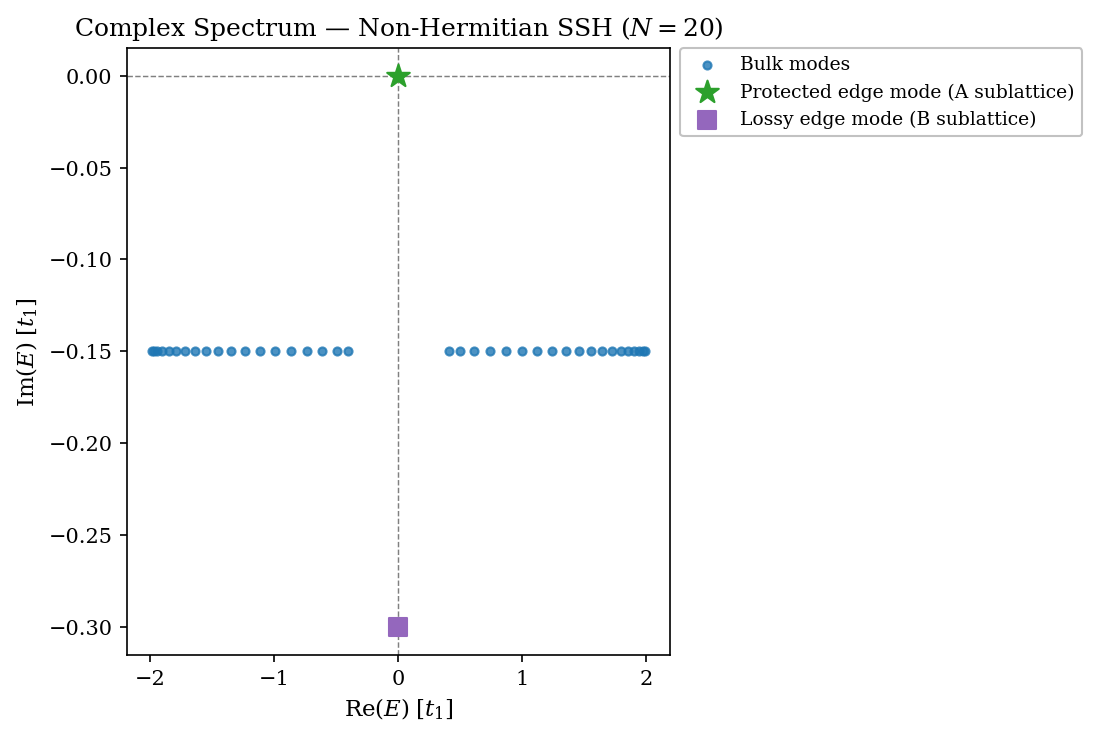

In [3]:
# --- Plot 1: Complex spectrum ---
fig, ax = nt.plotting.plot_complex_spectrum(evals, edge_info, p['N'])
nt.plotting.save_fig(fig, Path('..') / get_figure_dir(cfg, '01_theory_nonhermitian_lattices'), "01_complex_spectrum")
plt.show()


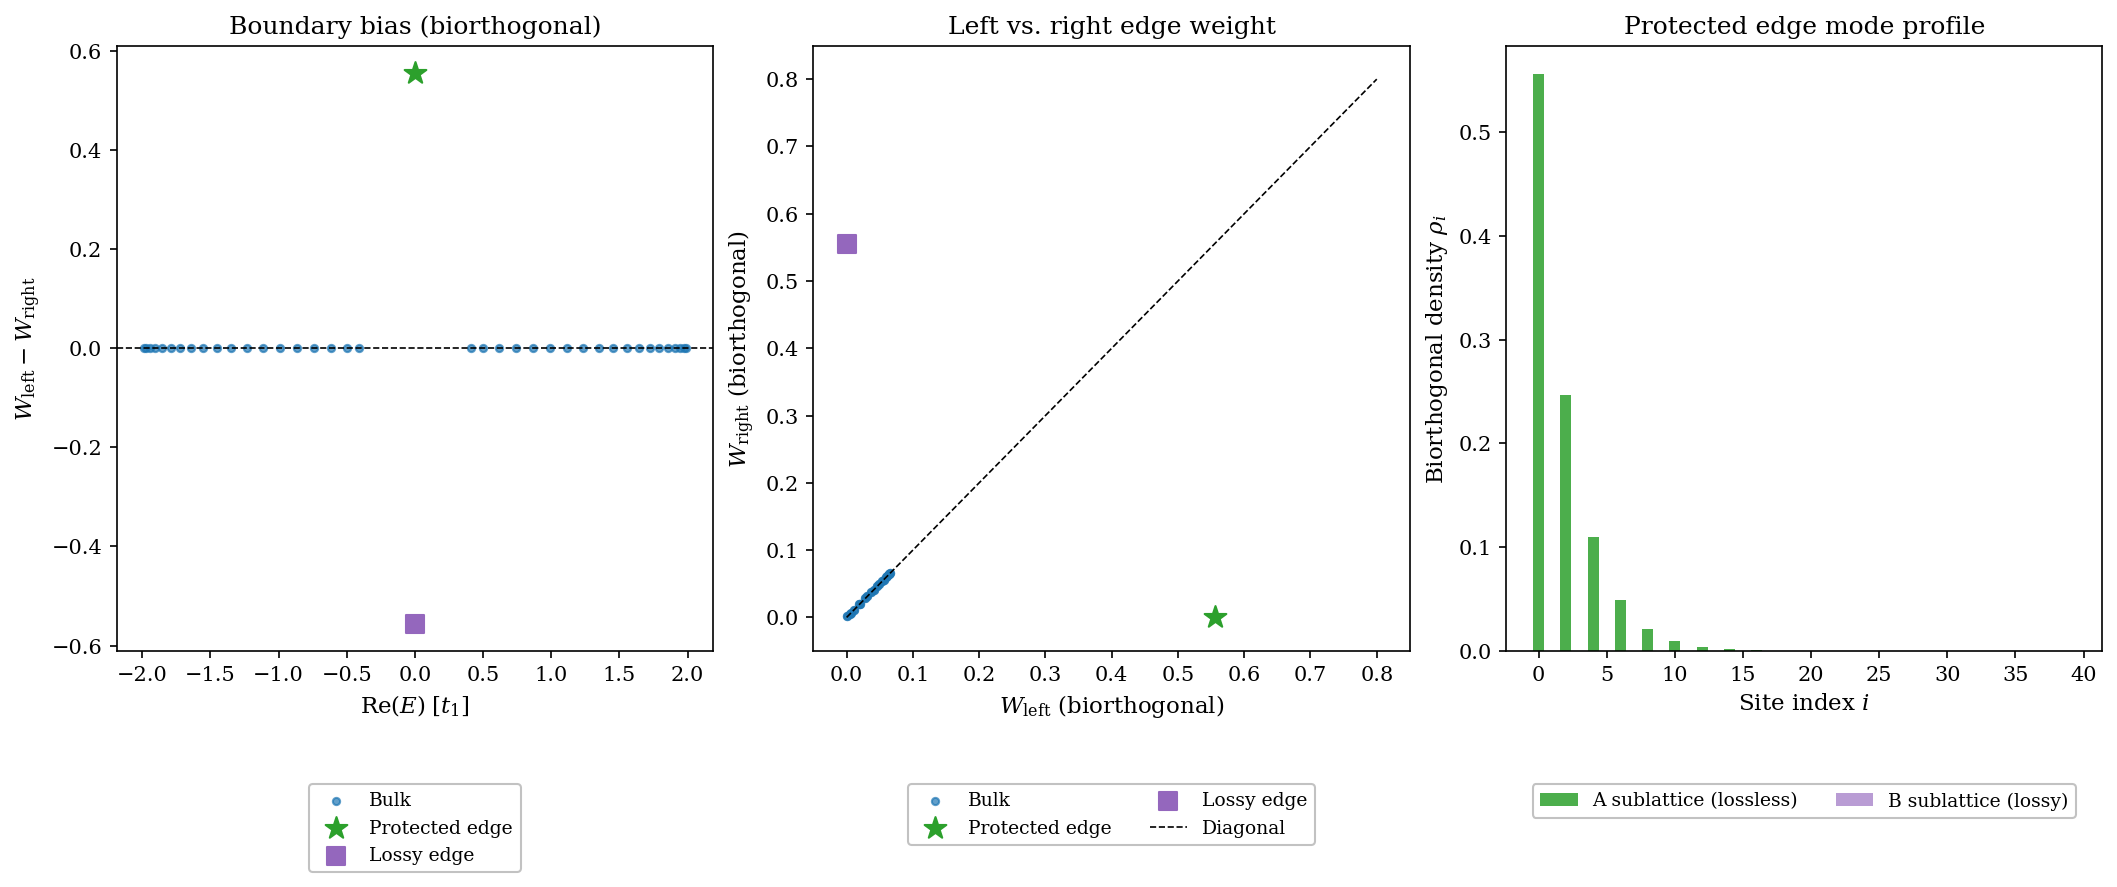

In [4]:
# --- Plot 2: Edge characterization (3-panel) ---
fig, axes = nt.plotting.plot_edge_characterization(
    evals, evecs, left_w, right_w, bio_density, edge_info, p['N'])
nt.plotting.save_fig(fig, Path('..') / get_figure_dir(cfg, '01_theory_nonhermitian_lattices'), "02_edge_characterization")
plt.show()


**Key results:**
- The protected edge mode has $\mathrm{Im}(E) \approx 0$ — it is decoupled from the
  B-sublattice loss channel.
- Biorthogonal boundary bias cleanly separates edge modes from bulk states.
- Spatial profile confirms exponential localization at the left boundary on A sites.
- Reciprocal hopping rules out non-Hermitian skin effects as the origin of localization.
